# ⚽ The Home Advantage in the Premier League: Crowd Impact on Performance
**Author: Leonardo Leal Linhares Dias**

In this notebook, we investigate the impact of crowd presence in stadiums during Premier League matches. We compare two distinct seasons:
* **2018/2019 (With Crowd):** Traditional scenario with full stadiums.
* **2020/2021 (Closed Doors):** Pandemic scenario played behind closed doors.

The goal is to visualize how the "home advantage" unfolds in **offensive** metrics (Goals and Shots) and **disciplinary** metrics (Fouls committed and Yellow Cards).

In [ ]:
# Essential libraries
import pandas as pd
import altair as alt
import warnings

# Ignores harmless system warnings for a cleaner notebook output
warnings.filterwarnings('ignore')

# Forces Altair to render charts as static SVG images in GitHub
alt.renderers.enable('svg')

# Disables Altair row limit
alt.data_transformers.disable_max_rows()

# 1. Load Data
df_1819 = pd.read_csv("../data/season-1819.csv")
df_2021 = pd.read_csv("../data/season-2021.csv")

# 2. Add Contextual Categorical Variable
df_1819['Season'] = '18/19 (With Crowd)'
df_2021['Season'] = '20/21 (Closed Doors)'

# 3. Concatenate datasets
df = pd.concat([df_1819, df_2021], ignore_index=True)

print(f"Total matches loaded: {df.shape[0]}")

Total matches loaded: 760


### 1. Analysis of Aggressiveness and Discipline

To compare the global average performance between home and away teams, we use a panel of **grouped bar charts**. 
* **Marks:** Lines (bars).
* **Channels:** Length/Vertical position (quantitative) and Color (categorical - Home vs. Away).

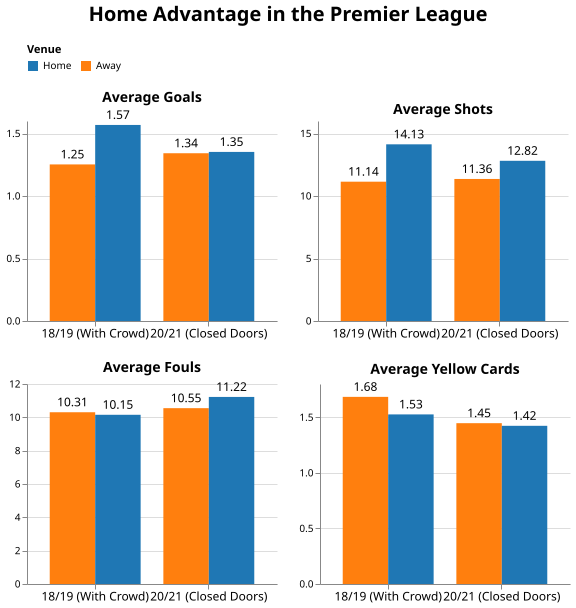

In [ ]:
# 1. Melt Data
records = []
for idx, row in df.iterrows():
    temp = row['Season']
    records.append({'Season': temp, 'Venue': 'Home', 'Metric': 'Goals', 'Value': row['FTHG']})
    records.append({'Season': temp, 'Venue': 'Away', 'Metric': 'Goals', 'Value': row['FTAG']})
    records.append({'Season': temp, 'Venue': 'Home', 'Metric': 'Shots', 'Value': row['HS']})
    records.append({'Season': temp, 'Venue': 'Away', 'Metric': 'Shots', 'Value': row['AS']})
    records.append({'Season': temp, 'Venue': 'Home', 'Metric': 'Fouls', 'Value': row['HF']})
    records.append({'Season': temp, 'Venue': 'Away', 'Metric': 'Fouls', 'Value': row['AF']})
    records.append({'Season': temp, 'Venue': 'Home', 'Metric': 'Yellow Cards', 'Value': row['HY']})
    records.append({'Season': temp, 'Venue': 'Away', 'Metric': 'Yellow Cards', 'Value': row['AY']})

df_melted = pd.DataFrame(records)

# 2. Group by Mean
df_grouped = df_melted.groupby(['Season', 'Metric', 'Venue'])['Value'].mean().reset_index()

# 3. Chart Function
def create_metric_chart(metric_name, show_legend=False):
    df_filtered = df_grouped[df_grouped['Metric'] == metric_name]
    legend = alt.Legend(title='Venue', orient='top') if show_legend else None

    bars = alt.Chart(df_filtered).mark_bar().encode(
        x=alt.X('Season:N', title=None, axis=alt.Axis(labelAngle=0, labelFontSize=12)),
        xOffset='Venue:N',
        y=alt.Y('Value:Q', title=None),
        color=alt.Color('Venue:N', legend=legend, scale=alt.Scale(domain=['Home', 'Away'], range=['#1f77b4', '#ff7f0e'])),
        tooltip=[alt.Tooltip('Venue:N', title='Venue'), alt.Tooltip('Value:Q', title='Average', format='.2f')]
    )

    texts = alt.Chart(df_filtered).mark_text(align='center', baseline='bottom', dy=-3, fontSize=12).encode(
        x=alt.X('Season:N'), xOffset='Venue:N', y=alt.Y('Value:Q'),
        text=alt.Text('Value:Q', format='.2f'), color=alt.value('black')
    )

    return (bars + texts).properties(width=250, height=200, title=alt.TitleParams(f'Average {metric_name}', fontSize=14))

# 4. Generate & Organize Charts
g1 = create_metric_chart('Goals', show_legend=True)
g2 = create_metric_chart('Shots')
g3 = create_metric_chart('Fouls')
g4 = create_metric_chart('Yellow Cards')

bar_panel = alt.vconcat(
    alt.hconcat(g1, g2),
    alt.hconcat(g3, g4)
).properties(
    title=alt.TitleParams('Home Advantage in the Premier League', fontSize=20, anchor='middle', dy=-15)
).configure_view(stroke='transparent')

bar_panel.save('../assets/bar_chart_en.svg')
bar_panel

### 2. Offensive Convergence: Granular Performance

To understand if the global average phenomenon applies to most individual clubs, we use **Scatter Plots**.
* **Marks:** Points (representing each club).
* **Channels:** Horizontal position (Average Home Goals) and Vertical position (Average Away Goals).

We added a **reference line ($y = x$)**. Teams below the line score more at home; teams above score more away. We expect to see a convergence (points clustering around the line) in the season without a crowd.

/home/leonardo/faculdade/2026_1/comp_grafica/premier-league-home-advantage/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3748: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  exec(code_obj, self.user_global_ns, self.user_ns)


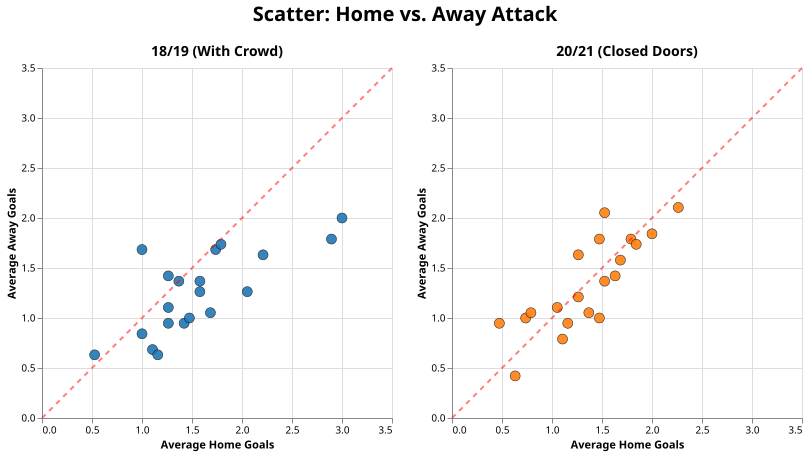

In [ ]:
# 1. Calculate Average Goals
home_avg = df.groupby(['Season', 'HomeTeam'])['FTHG'].mean().reset_index()
home_avg.columns = ['Season', 'Team', 'Avg_Home_Goals']

away_avg = df.groupby(['Season', 'AwayTeam'])['FTAG'].mean().reset_index()
away_avg.columns = ['Season', 'Team', 'Avg_Away_Goals']

df_times = pd.merge(home_avg, away_avg, on=['Season', 'Team'])

# 2. Setup Hover Interactions
hover_cor = alt.selection_point(name='hover_cor', on='mouseover', fields=['Team'], clear='mouseout', empty=True)
hover_tamanho = alt.selection_point(name='hover_tamanho', on='mouseover', fields=['Team'], clear='mouseout', empty=False)

# 3. Base Scatter Plot
base_scatter = alt.Chart(df_times).mark_circle(stroke='black').encode(
    x=alt.X('Avg_Home_Goals:Q', title='Average Home Goals', scale=alt.Scale(domain=[0, 3.5])),
    y=alt.Y('Avg_Away_Goals:Q', title='Average Away Goals', scale=alt.Scale(domain=[0, 3.5])),
    size=alt.condition(hover_tamanho, alt.value(350), alt.value(100)),
    strokeWidth=alt.condition(hover_tamanho, alt.value(2), alt.value(0.5)),
    opacity=alt.condition(hover_cor, alt.value(0.9), alt.value(0.2)),
    tooltip=[
        alt.Tooltip('Team:N', title='Club'),
        alt.Tooltip('Season:N', title='Context'),
        alt.Tooltip('Avg_Home_Goals:Q', title='Avg Home', format='.2f'),
        alt.Tooltip('Avg_Away_Goals:Q', title='Avg Away', format='.2f')
    ]
).add_params(hover_cor, hover_tamanho)

# 4. Reference Line (y = x)
linha_ref = alt.Chart(pd.DataFrame({'x': [0, 3.5], 'y': [0, 3.5]})).mark_line(
    color='red', strokeDash=[5, 5], opacity=0.5
).encode(x='x:Q', y='y:Q')

# 5. Layer Charts by Season
chart_1819 = alt.layer(
    base_scatter.transform_filter(alt.datum.Season == '18/19 (With Crowd)').encode(
        color=alt.condition(hover_cor, alt.value('#1f77b4'), alt.value('lightgray'))
    ), linha_ref
).properties(title=alt.TitleParams('18/19 (With Crowd)', fontSize=14, fontWeight='bold'), width=350, height=350)

chart_2021 = alt.layer(
    base_scatter.transform_filter(alt.datum.Season == '20/21 (Closed Doors)').encode(
        color=alt.condition(hover_cor, alt.value('#ff7f0e'), alt.value('lightgray'))
    ), linha_ref
).properties(title=alt.TitleParams('20/21 (Closed Doors)', fontSize=14, fontWeight='bold'), width=350, height=350)

# 6. Concatenate & Render
interactive_chart = alt.hconcat(chart_1819, chart_2021).properties(
    title=alt.TitleParams('Scatter: Home vs. Away Attack', fontSize=20, anchor='middle', dy=-15)
).configure_view(stroke='transparent')

interactive_chart.save('../assets/scatter_plot_en.svg')
interactive_chart